In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

PLOTS_DIR = "plots"
if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)
RNG = np.random.default_rng(42)  # reproducible random number generator

def save_plot(fig, filename):
    fig_file_path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)


# Task 3.a

In [2]:
n = 20  # number of Bernoulli variables per repetition
p = 0.35  # mean of each Bernoulli variable
num_repetitions = 1_000_000

# simulate 1,000,000 repetitions of 20 i.i.d. Bernoulli(p) draws
samples = RNG.binomial(1, p, size=(num_repetitions, n))
sample_means = samples.mean(axis=1)


### 1. Empirical frequency

In [3]:
alphas = np.arange(0.5, 1.0001, 0.05)

# for each alpha, the empirical frequency is the fraction of repetitions
# whose sample mean is at least alpha
empirical_freq = np.array([np.mean(sample_means >= a) for a in alphas])

for a, f in zip(alphas, empirical_freq):
    print(f"alpha = {a:.2f}: empirical frequency = {f:.6f}")


alpha = 0.50: empirical frequency = 0.121509
alpha = 0.55: empirical frequency = 0.052834
alpha = 0.60: empirical frequency = 0.006037
alpha = 0.65: empirical frequency = 0.001505
alpha = 0.70: empirical frequency = 0.000319
alpha = 0.75: empirical frequency = 0.000051
alpha = 0.80: empirical frequency = 0.000007
alpha = 0.85: empirical frequency = 0.000000
alpha = 0.90: empirical frequency = 0.000000
alpha = 0.95: empirical frequency = 0.000000
alpha = 1.00: empirical frequency = 0.000000


### 2. Why this granularity of $\alpha$ is sufficient

Since each $X_i \in \{0, 1\}$, the sum $\sum_{i=1}^{20} X_i$ can only take the
integer values $0, 1, \dots, 20$. Consequently the sample mean
$\frac{1}{20}\sum_{i=1}^{20} X_i$ can only take values on the grid
$\{0, \frac{1}{20}, \frac{2}{20}, \dots, 1\} = \{0, 0.05, 0.10, \dots, 1\}$, i.e.
multiples of $0.05$. The event $\left\{\frac{1}{20}\sum_i X_i \ge \alpha\right\}$
is therefore identical for any two values of $\alpha$ that fall in the same
half-open interval $(k \cdot 0.05,\, (k+1)\cdot 0.05]$, since no achievable
value of the sample mean lies strictly between two consecutive multiples of
$0.05$. Taking $\alpha = 0.51$ instead of $\alpha = 0.5$ would exclude the
achievable value $0.5$ from the event, giving exactly the same probability as
$\alpha = 0.55$ — it provides no new information beyond what the $0.05$-spaced
grid already captures.

### 3. Markov's bound

In [4]:
mu = p  # E[mu_hat_n] = mu = p (mu_hat_n is the sample mean, following the slides' notation)

def markov_bound(alphas, mu):
    # Markov's inequality (slide 11): P(X >= eps) <= E[X] / eps, valid for X >= 0.
    # Applied to X = mu_hat_n (non-negative), with eps = alpha:
    #   P(mu_hat_n >= alpha) <= E[mu_hat_n] / alpha = mu / alpha
    return np.minimum(mu / alphas, 1.0)

markov = markov_bound(alphas, mu)
print(markov)


[0.7        0.63636364 0.58333333 0.53846154 0.5        0.46666667
 0.4375     0.41176471 0.38888889 0.36842105 0.35      ]


### 4. Chebyshev's bound

In [5]:
var_X1 = p * (1 - p)  # Var(X_1), a single Bernoulli(p) variable

def chebyshev_bound(alphas, mu, var_X1, n):
    # Chebyshev's inequality for i.i.d. variables (slide 14, corollary):
    #   P(|mu_hat_n - mu| >= eps) <= Var(X_1) / (n * eps^2)
    # We only need the one-sided tail mu_hat_n >= alpha (alpha > mu), so we
    # bound the (larger) two-sided event with eps = alpha - mu:
    #   P(mu_hat_n >= alpha) <= P(|mu_hat_n - mu| >= alpha - mu) <= Var(X_1) / (n * (alpha - mu)^2)
    eps = alphas - mu
    with np.errstate(divide="ignore"):
        bound = np.where(eps > 0, var_X1 / (n * np.square(eps)), 1.0)
    return np.minimum(bound, 1.0)

chebyshev = chebyshev_bound(alphas, mu, var_X1, n)
print(chebyshev)


[0.50555556 0.284375   0.182      0.12638889 0.09285714 0.07109375
 0.05617284 0.0455     0.03760331 0.03159722 0.02692308]


### 5. Hoeffding's bound

In [6]:
def hoeffding_bound(alphas, mu, n):
    # Hoeffding's inequality for i.i.d. variables with support [0, 1] (slide 17,
    # statement (i) applied to mu_hat_n instead of S_n):
    #   P(mu_hat_n - mu >= eps) <= exp(-2 * n * eps^2)
    # With eps = alpha - mu:
    #   P(mu_hat_n >= alpha) <= exp(-2 * n * (alpha - mu)^2)
    eps = alphas - mu
    with np.errstate(invalid="ignore"):
        bound = np.where(eps > 0, np.exp(-2 * n * np.square(eps)), 1.0)
    return np.minimum(bound, 1.0)

hoeffding = hoeffding_bound(alphas, mu, n)
print(hoeffding)


[4.06569660e-01 2.01896518e-01 8.20849986e-02 2.73237224e-02
 7.44658307e-03 1.66155727e-03 3.03539138e-04 4.53999298e-05
 5.55951324e-06 5.57390369e-07 4.57533877e-08]


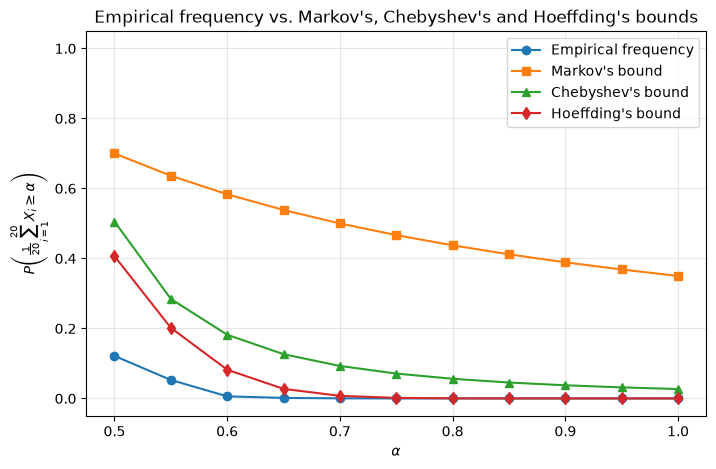

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, empirical_freq, "o-", label="Empirical frequency")
ax.plot(alphas, markov, "s-", label="Markov's bound")
ax.plot(alphas, chebyshev, "^-", label="Chebyshev's bound")
ax.plot(alphas, hoeffding, "d-", label="Hoeffding's bound")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$P\left(\frac{1}{20}\sum_{i=1}^{20} X_i \geq \alpha\right)$")
ax.set_title("Empirical frequency vs. Markov's, Chebyshev's and Hoeffding's bounds")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

save_plot(fig, "markov_chebyshev_hoeffding.png")


### 6. Comparison of the four plots

The empirical frequency is by far the smallest curve, decaying sharply as
$\alpha$ grows past the mean $p = 0.35$. All three bounds are, as expected,
above (or equal to) the true probability for every $\alpha$, but they differ
substantially in tightness:

- **Markov's bound** is the loosest by a wide margin. It only uses the mean
  of the random variable and decays as $O(1/\alpha)$, remaining close to $1$
  even for large $\alpha$.
- **Chebyshev's bound** is tighter than Markov's for most of the range, since
  it additionally exploits the (small) variance of the sample mean, but it
  still decays only polynomially and is far looser than the true probability.
- **Hoeffding's bound** is by far the tightest of the three. Because it
  decays exponentially in $\alpha$ (more precisely in $n(\alpha-p)^2$), it
  tracks the rapid decay of the empirical frequency much more closely,
  especially for $\alpha$ close to $1$.

Overall, the ranking from loosest to tightest is Markov $\ge$ Chebyshev $\ge$
Hoeffding $\ge$ true probability, which matches the fact that each successive
inequality uses more information about the distribution (mean only, then
mean and variance, then the boundedness of the variables together with
independence).

### 7. Exact probabilities for $\alpha = 1$ and $\alpha = 0.95$

In [8]:
from scipy.stats import binom

def exact_probability(alpha, n, p):
    # P((1/n) sum X_i >= alpha) = P(sum X_i >= alpha * n), sum X_i ~ Binomial(n, p)
    k = int(np.ceil(alpha * n - 1e-9))
    return 1 - binom.cdf(k - 1, n, p)

for a in [1.0, 0.95]:
    exact = exact_probability(a, n, p)
    print(f"alpha = {a:.2f}: exact probability = {exact:.6e}")


alpha = 1.00: exact probability = 7.609583e-10
alpha = 0.95: exact probability = 2.902513e-08
